## Aggregate runs

## Normalization + ILR Transform

In [ ]:
cra.print_configs(paths=True)

In [ ]:
config = deepcopy(full_config)
config['-i'] = True
agg = [("--ap", "--annealing"), "-i", "-w"]
cra.plot(
    config,
    metrics=["f1"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["tpr_fpr"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["em_hd", "em_gt_hd", "mean_relerr_agg", "transition_null_to_alt"],
    agg=agg,
    plot_type="violin",
);


## Transition Prior

In [ ]:
cra.print_configs(paths=True)

In [ ]:
config['--rho'] = 0.9
config['--beta'] = 4
agg = [("--rho", "--beta"), '-w']
cra.plot(
    config,
    metrics=["f1"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["tpr_fpr"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["em_hd", "em_gt_hd", "transition_null_to_alt"],
    agg=agg,
    plot_type="violin",
);

## Best config
rho=0.9, beta=4
free/free
w25k s20k
Equal init

In [ ]:
config = deepcopy(full_config)
config['-w'] = '25k'
config['-s'] = 0.8
config["--double-variance-init"] = False
config["--rho"] = 0.9
config["--beta"] = 4
cra.plot(
    config,
    metrics=["f1"],
    agg=["-w"] + aggB,
)
cra.plot(
    config,
    metrics=["tpr_fpr"],
    agg=["-w"] + aggB[1:],
)
cra.plot(
    config,
    metrics=["em_hd", "em_gt_hd", "transition_null_to_alt", "transition_alt_to_null"],
    agg=["-w"] + aggB,
    plot_type="violin",
);

### Repulsion/annealing

In [ ]:
cra.print_configs(paths=True)

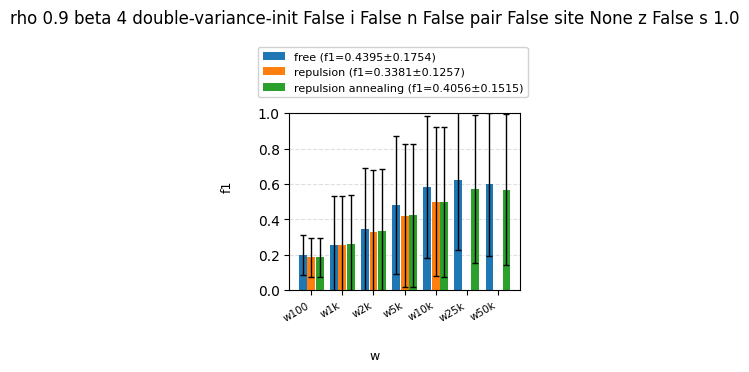

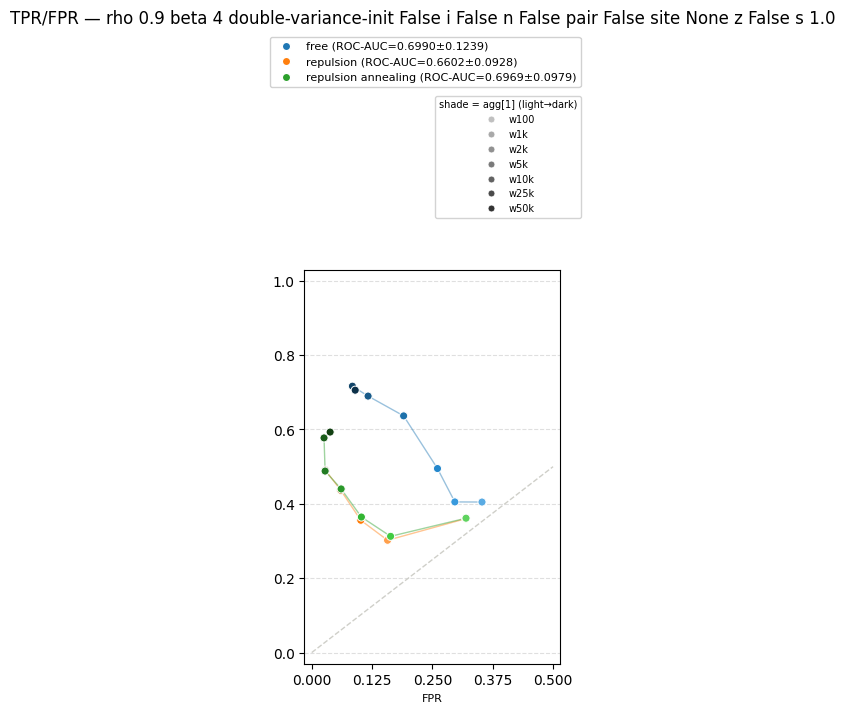

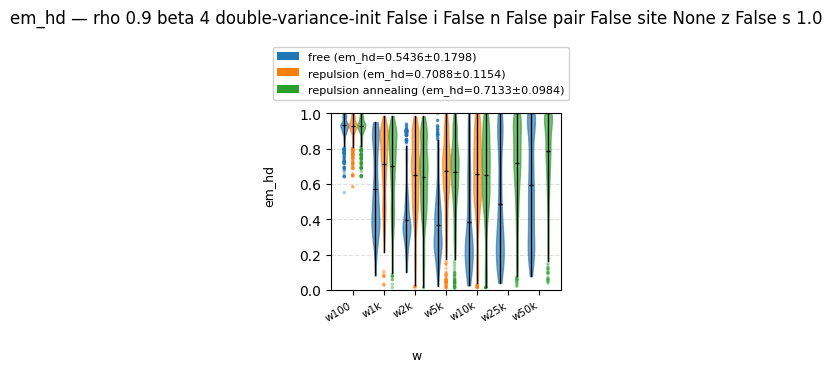

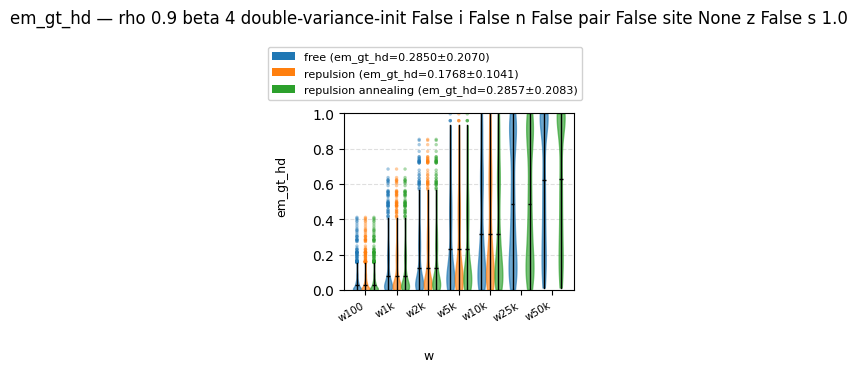

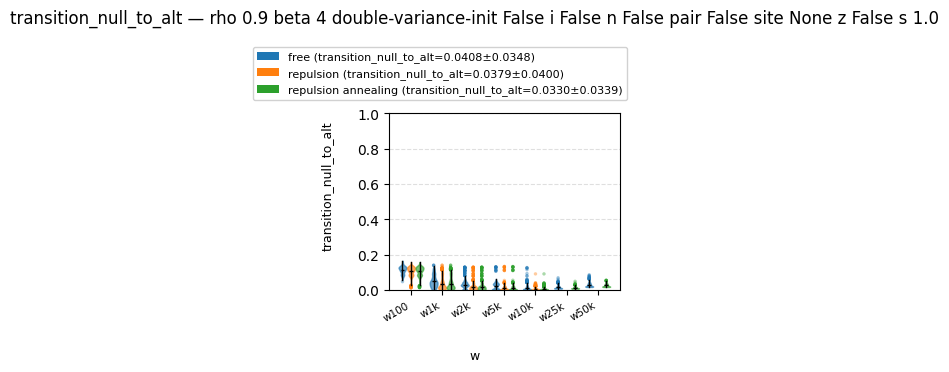

In [2]:
config = deepcopy(full_config)
agg = [("--ap", "--annealing"), "-w"]
cra.plot(
    config,
    metrics=["f1"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["tpr_fpr"],
    agg=agg,
)
cra.plot(
    config,
    metrics=["em_hd", "em_gt_hd", "transition_null_to_alt"],
    agg=agg,
    plot_type="violin",
);

In [ ]:
windows = ["1", "10", "100", "1k", "2k", "5k", "10k", "25k", "50k"]
steps = "1.0"
other_configs = {"--double-variance-init": False, "--rho": [None], "--beta": [None]}
agg = ["pattern", "em_gt_hd_bin", ("--ap", "--annealing")]
cra.plot({"-w": windows, "-s": steps, **other_configs}, metrics=["f1_signed", "roc_auc_signed"], agg=agg, plot_type="heatmap");

## Double Variance Init

In [ ]:
cra.print_configs({"-w": windows, "-s": steps, **other_configs}, metrics=['f1'],paths=True)

In [ ]:
windows = ["1", "10", "100", "1k", "2k", "5k", "10k", "25k", "50k"]
steps = "1.0"
other_configs = {}#{"--rho": [0.9], "--beta": [4]}
agg = ["--double-variance-init", ("--ap", "--annealing"),  "-w", "fraction_bin"]
cra.plot(
    {"-w": windows, "-s": steps, **other_configs},
    metrics=["f1"],
    agg=agg,
)
cra.plot(
    {"-w": windows, "-s": steps, **other_configs},
    metrics=["tpr_fpr"],
    agg=agg,
)
cra.plot(
    {"-w": windows, "-s": steps, **other_configs},
    metrics=["em_hd", "em_gt_hd", "transition_null_to_alt",],
    agg=agg,
    plot_type="violin",
);

In [1]:
from bench.utils import CrossRunAnalysis
from copy import deepcopy

cra = CrossRunAnalysis()
cra.compute_hd_bin_edges()
aggB = ["x_bin", "merged_category", "fraction_bin"]
full_config = {"--rho": 0.9, "--beta": 4, "--double-variance-init": False, "-i": False, "-n": False, 
               "--pair": False, "--site": [None], "-z": False, "-s": 1.0, "-w": [10, 100, "1k", "2k", "5k", "10k", "25k", "50k"]}

Ground Truth HD vs. Branch Length

In [ ]:
cra.plot(
    full_config,
    metrics=["em_hd", "em_gt_hd"],
    agg=[""] + aggB,
    plot_type="violin",
);

### Heatmap: F1/ROC-AUC by window x step size

In [ ]:
config = deepcopy(full_config)
config['-w'] = ["1", "10", "100", "1k", "2k", "5k", "10k", "25k", "50k"]
config['-s'] = ["0.8", "1.0", "1k"]
cra.plot(
    config, metrics=["f1", "roc_auc"], agg=["-w", "-s"], plot_type="heatmap");